In [1]:
import jax
jax.config.update("jax_enable_x64", True)


In [2]:
import os
import time
from datetime import datetime

import numpy as np
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

import tensorflow_probability.substrates.jax as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

# --- new (scene) API ---------------------------------------------------------
from gigalens.jax.scene import Component, Plane, LensModel
from gigalens.jax.profiles.mass.epl import EPL
from gigalens.jax.profiles.light.sersic import SersicEllipse
from gigalens.jax.cosmo import w0waCDM_Cosmo
from gigalens.jax.scene_prob_model import ImageData, ProbModel
from gigalens.jax.scene_simulator import SceneSimulator
from gigalens.simulator import SimulatorConfig

# --- research-side pipeline / diagnostics (gigalens_research) ----------------
from gigalens_research.inference_utils import (
    InferenceContext, Pipeline, MAPStage, BridgeStage, MCLMCStage,
)
from gigalens_research.plotting import PosteriorReport, PipelineReport
import photutils.psf as psf

E0803 14:51:45.483783 1265893 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0803 14:51:45.483824 1265894 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0803 14:51:45.483883 1265895 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


In [11]:
import bullseye
import importlib
importlib.reload(bullseye)
from bullseye import make_bullseye, standard_pipeline, make_prob_grid

num_free_params = 22
z_param_names   = ['cosmo/Om0', 'cosmo/w0', 'planes/0/mass/0/center_x', 'planes/0/mass/0/center_y', 'planes/0/mass/0/e1', 'planes/0/mass/0/e2', 'planes/0/mass/0/s_E', 'planes/0/mass/0/theta_E', 'planes/1/light/0/Ie', 'planes/1/light/0/R_sersic', 'planes/1/light/0/center_x', 'planes/1/light/0/center_y', 'planes/1/light/0/e1', 'planes/1/light/0/e2', 'planes/1/light/0/n_sersic', 'planes/2/light/0/Ie', 'planes/2/light/0/R_sersic', 'planes/2/light/0/center_x', 'planes/2/light/0/center_y', 'planes/2/light/0/e1', 'planes/2/light/0/e2', 'planes/2/light/0/n_sersic']
USING Boring cosmology for cosmology truth: {'H0': 70.0, 'Om0': 0.3, 'k': 0.0, 'w0': -1.0, 'wa': 0.0}


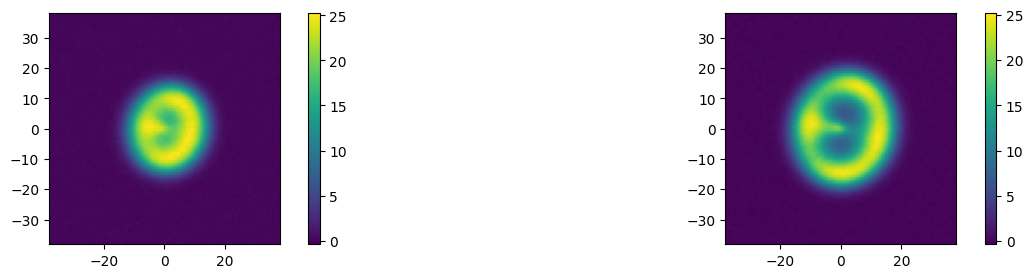

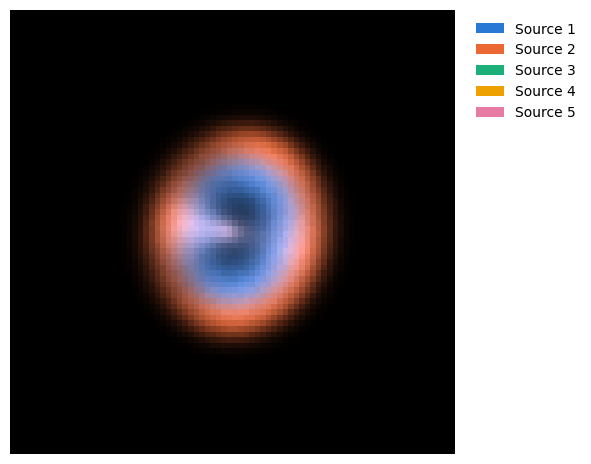

In [13]:

z_source1 = 1.0
z_source2 = 1.4
# z_source3 = 1.7
zs = [z_source1, z_source2]

lkw = {"n_sersic":0.5, "R_sersic":0.2}
prob_model, prob_model_dr, truth_scene, truth_def_ratio = make_bullseye(sample_wa=False, zs = zs,snr_scale=200., light_kwargs=lkw)
ctx = InferenceContext.from_prob_model(prob_model)
ctx_dr = InferenceContext.from_prob_model(prob_model_dr)

mams_kwargs= dict(target_acceptance=0.9, max_integration_steps=512, L_max_ratio=16.0, init_L=75)
pipeline = standard_pipeline(ctx, use_mams=True, n_chains=9, mams_kwargs=mams_kwargs)
pipeline_dr = standard_pipeline(ctx_dr, use_mams=True, n_chains=9)

In [ ]:
results_dir = os.path.join(
    os.path.expanduser("~"), "GIGALens-Code", "results",
    "sample_cosmology", "2spl_bullseye_hook_ns0.5_snrscale200", #
)
results_dir_dr = os.path.join(
    os.path.expanduser("~"), "GIGALens-Code", "results",
    "sample_cosmology", "2spl_bullseye_hook_dr_ns0.5_snrscale200", #
)
artifacts = pipeline.run(out_dir=results_dir, resume=True)
artifacts_dr = pipeline_dr.run(out_dir=results_dir_dr, resume=True)


MODEL CARD — effective forward model & inference setup
  Model      : LensModel(3 planes, 1 mass + 2 light components, 22 free params, cosmo=w0waCDM)
    plane 0: redshift=0.5  mass=[NFW_ELLIPSE_SLOPE]
    plane 1: redshift=1  light=[SERSIC_ELLIPSE]
    plane 2: redshift=1.4  light=[SERSIC_ELLIPSE]
  Cosmology  : w0waCDM z_lens=0.5 z_source_ref=1.4  H0=70, k=0, wa=0, Om0=sampled(UniformBij), w0=sampled(UniformBij)
  Trace      : deflection_ratio  (simulator)
  Parameters : 22 free  z-order sha1=59201e6d109c  dtypes={float32, float64}
  Amplitudes : lstsq=False n_basis=0 physical_reg=None
  Likelihood : mode=forward  event_size=12800  precision=float64  loss_norm=12800
    shares   : [0] ImageData 6400 (50%)  [1] ImageData 6400 (50%)
  Physicality: 0 error(s), 0 warning(s), 0 soft; 8 check(s) recorded
    [info] NFW_ELLIPSE_SLOPE[plane 0 mass 0].*: no physicality domains registered for this profile (pending audit; see PENDING_PHYSICALITY_AUDIT)
  Dataset 0  : ImageData 80x80  event=6400

/tmp/ipykernel_1265661/2383506896.py:9: UserWarning: [pipeline] mams: input hash changed; moved old run to /global/home/users/linusupson/GIGALens-Code/results/sample_cosmology/2spl_bullseye_hook_ns0.5_snrscale200/mams.stale-20260803T145418
  artifacts = pipeline.run(out_dir=results_dir, resume=True)


<div><progress max="4000" value="2601"></progress> 65.03% [2601/4000 00:00&lt;?]</div>

In [ ]:
 # pipeline_report = PipelineReport(pipeline)
# fig = pipeline_report.diagnostics("mclmc", chain=3)
# fig.show()

report = PosteriorReport(pipeline.posterior(), truth_x=truth_scene)
report.corner(kind="cosmology")
report.convergence_panel()
# report.full_report()
plt.show()

In [ ]:
report_dr = PosteriorReport(pipeline_dr.posterior(), truth_x=truth_def_ratio)
report_dr.corner(kind=["geometry"])
report_dr.convergence_panel()
# report_dr.full_report()
plt.show()

In [ ]:
ps = pipeline_dr.posterior()

In [ ]:
idxes = [1,]
dr_smps = jnp.stack([ps.flat_x[f'planes/{i}/geometry/deflection_ratio'] for i in idxes])
dr_median = jnp.median(dr_smps, axis=-1)
dr_cov = jnp.cov(dr_smps)
if len(dr_cov.shape) ==0:
    dr_cov = dr_cov[None, None]
zs_free_dr = [zs[i-1] for i in idxes]#[z_source1, z_source3, z_source4, z_source5]

In [ ]:

import bullseye
importlib.reload(bullseye)
from bullseye import make_prob_grid
# observed = {
#     "deflect_ratio_obs": np.expand_dims(np.array(dr_medians), 1),
#     "deflect_ratio_obs_err": np.expand_dims(np.array(dr_stds), 1),
#     "z_source": np.expand_dims(np.array(zs), 1),
# }

cos=prob_model.model.cosmo.profile
observed = {
    "deflect_ratio_obs": np.expand_dims(dr_median, 1),
    "deflect_ratio_cov": dr_cov,
    # "deflect_ratio_cov_det": jnp.abs(jnp.linalg.det(dr_cov)),
    "z_source": np.expand_dims(np.array(zs_free_dr), 1),
}
like, om_w_grid = make_prob_grid(observed, cos, n_grid=1000)

In [13]:

# cosmo_prior = tfd.JointDistributionNamed(
#     dict(
#         Om0=tfd.Uniform(0.0, 1.0),
#         w0=tfd.Uniform(-2.0, -1/3),
#     )
# )

# # # chi2
# # def lens_cosmo_chi2(Om0, w0, z_source,
# #                     deflect_ratio_obs, deflect_ratio_cov_det, deflect_ratio_cov_inv,
# #                     cosmo):
# #     def mapped_dr(Om0, w0):
# #         return cosmo.deflection_ratio(z_source, Om0=Om0, w0=w0, H0=70., k=0.0)
# #     deflect_ratio = mapped_dr(Om0, w0)
# #     delta = deflect_ratio - deflect_ratio_obs
# #     chi2 = delta * deflect_ratio_cov_inv.dot(delta)
# #     return jnp.sum(chi2, axis=0)  # sum over redshifts

# # likelihood
# def lens_cosmo_loglike(Om0, w0, z_source,
#                     deflect_ratio_obs, deflect_ratio_cov_det, deflect_ratio_cov_inv,
#                     cosmo):
#     def mapped_dr(Om0, w0):
#         return cosmo.deflection_ratio(z_source, Om0=Om0, w0=w0, H0=70., k=0.0, wa=0.0)
#     deflect_ratio = mapped_dr(Om0, w0)
#     delta = deflect_ratio - deflect_ratio_obs
#     chi2 = delta * deflect_ratio_cov_inv.dot(delta)
#     normalization = jnp.log(2 * jnp.pi * deflect_ratio_cov_det)
#     log_like = -1 / 2 * (chi2 + normalization)
#     return jnp.sum(log_like, axis=0)  # sum over redshifts

# # log_prob
# def lens_cosmo_logprob(state, observation, cosmo):
#     log_prior = cosmo_prior.log_prob(state)
#     log_like = lens_cosmo_loglike(cosmo=cosmo, **state, **observation)
#     return log_like + log_prior


# def logsumexp_norm(log_prob):
#     c = jnp.max(log_prob)
#     logsumexp = c + jnp.log(jnp.nansum(jnp.exp(log_prob - c)))
#     return log_prob - logsumexp

    
# def make_prob_grid(observation, cosmo, n_grid=400, plane_indexes=None):
#     if plane_indexes is None:
#         plane_indexes = np.array(range(len(observation['z_source'])))
#         # print(plane_indexes)
    
#     Om0_grid, w0_grid = jnp.linspace(0, 1, n_grid), jnp.linspace(-2, -1/3, n_grid)
#     Om0_grid, w0_grid = jnp.meshgrid(Om0_grid, w0_grid, indexing='ij')
    
#     states = {
#         'Om0': Om0_grid.flatten(), 
#         'w0': w0_grid.flatten()
#     }

#     # obs_p = copy.deepcopy(observation)
#     selected_med = observation['deflect_ratio_obs'][plane_indexes]
#     selected_cov = observation['deflect_ratio_cov'][plane_indexes][:, plane_indexes]
#     # print(selected_cov)
#     obs_p = {}
#     obs_p["deflect_ratio_obs"] = selected_med
#     obs_p["deflect_ratio_cov_inv"] = jnp.linalg.inv(selected_cov)
#     obs_p["deflect_ratio_cov_det"] = jnp.abs(jnp.linalg.det(selected_cov))
#     obs_p["z_source"] = observation["z_source"][plane_indexes]

#     log_prob = lens_cosmo_logprob(states, obs_p, cosmo=cosmo)
#     log_prob = log_prob.reshape(Om0_grid.shape)
#     log_prob = np.array(log_prob).astype(np.float64)
#     log_prob = logsumexp_norm(log_prob)
#     prob = np.exp(log_prob)
#     return prob, (np.array(Om0_grid), np.array(w0_grid))




# # plotting posterior
# def get_ll_levels(like_grid, levels=[0.68, 0.955, 0.997]):
#     # Compute the density levels.
#     Hflat = like_grid.flatten()
#     inds = np.argsort(Hflat)[::-1]
#     Hflat = Hflat[inds]
#     sm = np.cumsum(Hflat)
#     sm /= sm[-1]
#     v = []
#     for level in levels:
#         v.append(Hflat[sm <= level][-1])
#     return sorted(v)

# # levels = get_ll_levels(like, levels=[0.68, 0.955, 0.997])
# # plt.contour(om_w_grid[0], om_w_grid[1], like, levels=levels, colors='k', linestyles=['--', ':', '-'])
# # plt.show()

In [ ]:
import corner
kw = lambda : dict(density=True)
stacked = np.stack([om_w_grid[0].flatten(),om_w_grid[1].flatten()]).T
fig = corner.corner(stacked,color="red", weights=np.array(like.flatten()), plot_datapoints=False, plot_density=False,truths=[0.3, -1.0], range=[(0.0, 1.0), (-2, -1/3)], hist_kwargs=kw(),)

cos_smps = np.stack([pipeline.posterior().flat_x[f'cosmo/Om0'], pipeline.posterior().flat_x[f'cosmo/w0']]).T
corner.corner(cos_smps, fig=fig, color='black', plot_datapoints=False, plot_density=False,hist_kwargs=kw(), labels=[r'$\Omega_m$', r'$w_0$'])
plt.show()
# om_w_grid[0].shape

In [ ]:
from matplotlib.patches import Patch

def plot_cosmo_contour(plane_indexes=None, fig=None, color='black', levels=(0.68, 0.95), label=None):
    like, om_w_grid = make_prob_grid(observed, cos, n_grid=1000, sample_wa=False, plane_indexes=plane_indexes)
    stacked = np.stack([om_w_grid[0].flatten(), om_w_grid[1].flatten()]).T
    fig = corner.corner(
        stacked,
        weights=np.array(like.flatten()),
        plot_datapoints=False,
        bins=50,
        contour_kwargs={'linewidths': 0.5},
        plot_density=False,
        fill_contours=True,
        truths=[0.3, -1.0],
        levels=levels,
        color=color,
        hist_kwargs=kw(),
        labels=[r'$\Omega_m$', r'$w_0$'],
        fig=fig,
    )

    if label is not None:
        if not hasattr(fig, '_legend_handles'):
            fig._legend_handles = []
        fig._legend_handles.append(Patch(facecolor=color, edgecolor=color, label=label))

        ndim = int(np.sqrt(len(fig.axes)))
        legend_ax = fig.axes[ndim - 1]  # top-right axis, standard corner-plot legend spot
        legend_ax.legend(handles=fig._legend_handles, loc='center', frameon=False)

    return fig

In [ ]:
fig=None
for i, c, l in zip([0, 1], ['y', 'g'], ['z=1, 1.4', 'z=1.4, 1.7']):
    
    fig =plot_cosmo_contour(plane_indexes=np.array([i,]), fig=fig, color=c, label = l)
fig = plot_cosmo_contour(fig=fig, label="All Planes")
fig.set_size_inches(10, 10)
fig.show()

In [ ]:
dr_stds = jnp.std(dr_smps, axis=-1)


plt.subplot(211)
plt.errorbar(zs_free_dr, dr_median,dr_stds,fmt='.', label='Measured deflection ratios')
plt.plot(jnp.linspace(0.5,1.8,101), cos.deflection_ratio(jnp.linspace(0.5,1.8,101), Om0=0.3, w0=-1, H0=70., wa=0.0, k=0.0),label=r'$\Lambda$CDM')
plt.title('Deflection ratio Hubble diagram')
plt.xlabel(r'Redshift')
plt.ylabel(r'$\eta$')
plt.legend()
plt.subplot(212)

dr_pred = cos.deflection_ratio(np.array(zs_free_dr), Om0=0.3, w0=-1, H0=70., wa=0.0, k=0.0)
plt.errorbar(zs_free_dr, dr_median-dr_pred,dr_stds,fmt='.', label='Measured difference')
plt.plot(jnp.linspace(0.5,1.8,101), jnp.zeros_like(jnp.linspace(0.5,1.8,101)),label=r'$\Lambda$CDM')
plt.title(r'Difference from $\Lambda$CDM')
plt.xlabel(r'Redshift')
plt.ylabel(r'$\Delta\eta$')

plt.tight_layout()
plt.show()